In [198]:
# regression-------->evaluation metrics ---r2 score,mae,mse,rmse
# classfication -----> confusion matrix, prcision , recall, f1score

In [137]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
df = pd.read_csv("bank-additional-full (3) (1).csv",sep = ";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


age – Age of the individual (in years).

job – Type of job (e.g., admin., technician, blue-collar).

marital – Marital status (e.g., married, single, divorced).

education – Highest level of education achieved.

default – Whether the person has credit in default (yes/no).

housing – Whether the person has a housing loan (yes/no).

loan – Whether the person has a personal loan (yes/no).

contact – Type of communication contact used (e.g., cellular, telephone).

month – Last contact month of the year (e.g., may, jun).

day_of_week – Day of the week of the last contact.

duration – Duration of the last contact in seconds.

campaign – Number of contacts performed during this campaign.

pdays – Days since the client was last contacted from a previous campaign (-1 means never).

previous – Number of contacts performed before this campaign.

poutcome – Outcome of the previous marketing campaign.

emp.var.rate – Employment variation rate (economic indicator).

cons.price.idx – Consumer price index (monthly economic indicator).

cons.conf.idx – Consumer confidence index (monthly economic indicator).

euribor3m – Euribor 3-month rate (economic indicator).

nr.employed – Number of employees (economic indicator).

y – Target variable; whether the client subscribed to a term deposit (yes/no).

In [139]:
#preprocessing vs eda
#pre--cleaning the data and str the data
#eda--explorartory data analysis-to get the insights from the data

In [140]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [141]:
df["y"].value_counts()

y
no     36556
yes     4640
Name: count, dtype: int64

In [142]:
df["job"].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1726
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [143]:
df["job"].value_counts()/len(df["job"])

job
admin.           0.252967
blue-collar      0.224617
technician       0.163669
services         0.096337
management       0.070973
retired          0.041894
entrepreneur     0.035341
self-employed    0.034491
housemaid        0.025729
unemployed       0.024612
student          0.021238
unknown          0.008010
Name: count, dtype: float64

In [144]:
#statsical summary of the data
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41195.000000,41196.000000,41196.000000,41196.000000,41196.000000,41196.000000,41195.000000,41196.000000,41196.000000,41196.000000
mean,40.030319,258.281265,2.567676,962.482547,0.173124,0.081656,93.575867,-40.504600,3.620787,5166.996405
std,10.431818,259.254211,2.769751,186.893451,0.494987,1.570894,0.578999,4.629972,1.734655,72.300104
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

# data cleaning 
*null
*duplicate
*outliers

In [146]:
df.isnull().sum()

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64

In [147]:
df.isnull().sum().sum()

76

In [148]:
#how to handel null values
#drop ---->dropna
#replace

In [149]:
# df.dropna(inplace=True)

# data is of two types
**numeric data -- replace mean/median**<--------------->
**cat data---replace with mode**

In [150]:
for col in df.columns:
    if df[col].dtype =="object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())
        

In [151]:
df.isnull().sum().sum()

0

In [152]:
#duplicated
df.duplicated().sum()

16

In [153]:
df.drop_duplicates(inplace = True)

In [154]:
df.duplicated().sum()

0

In [155]:
df.shape

(41183, 21)

# how to check outliears ------->numerical data----->boxplot

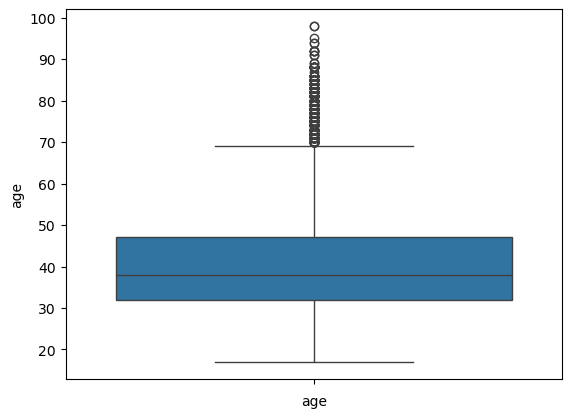

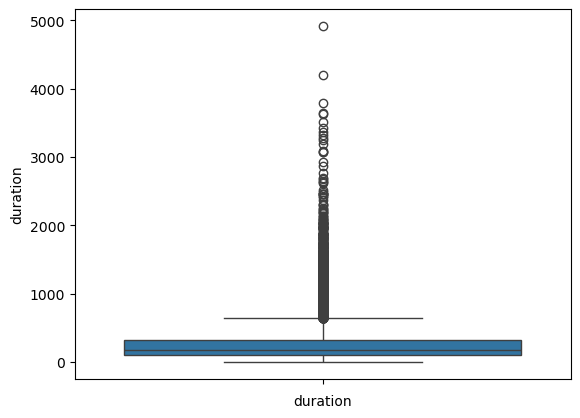

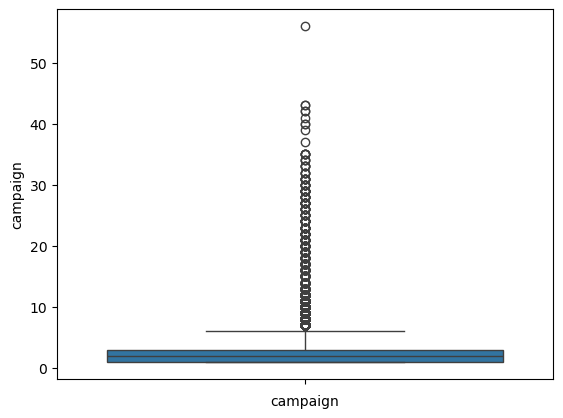

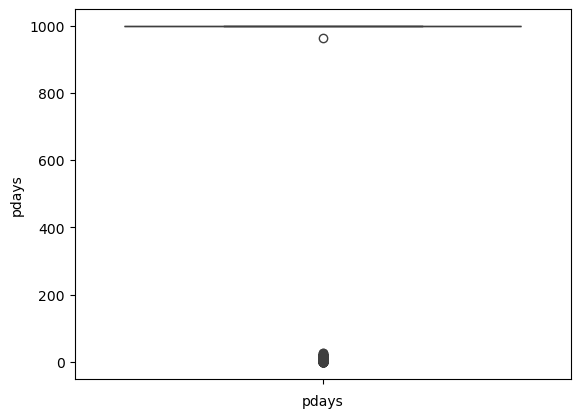

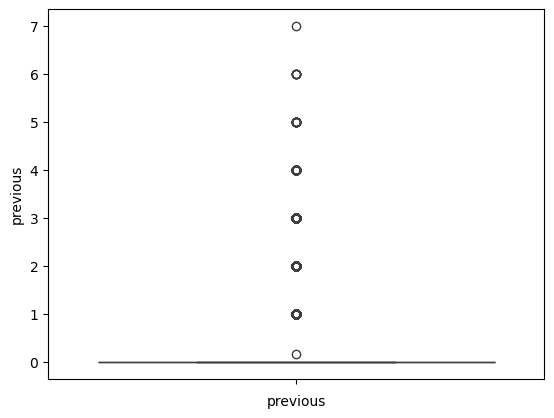

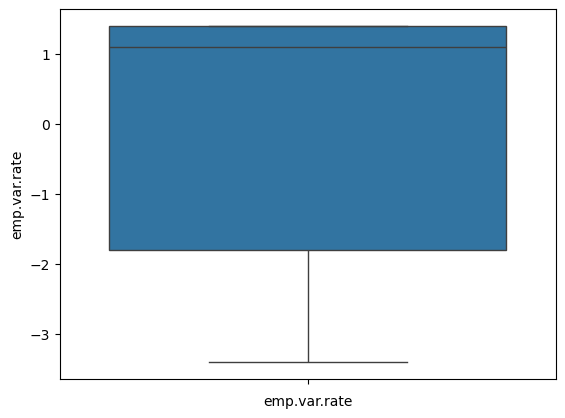

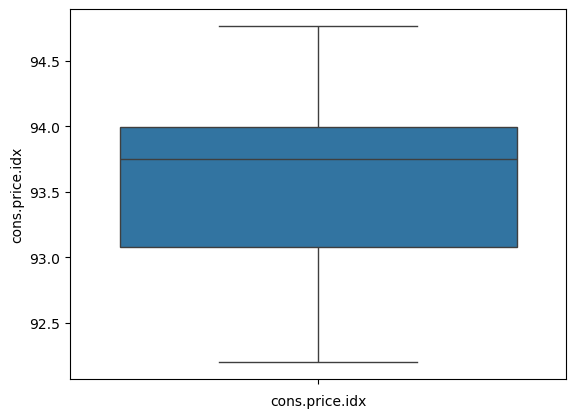

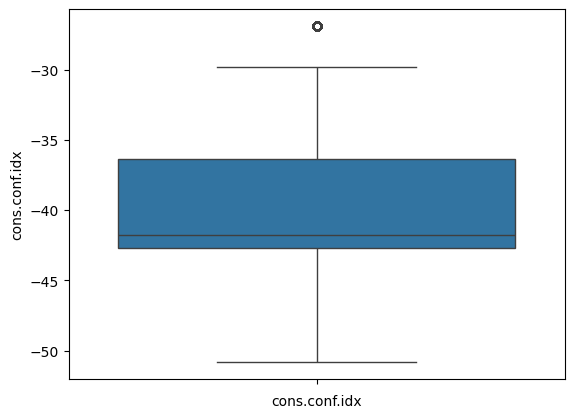

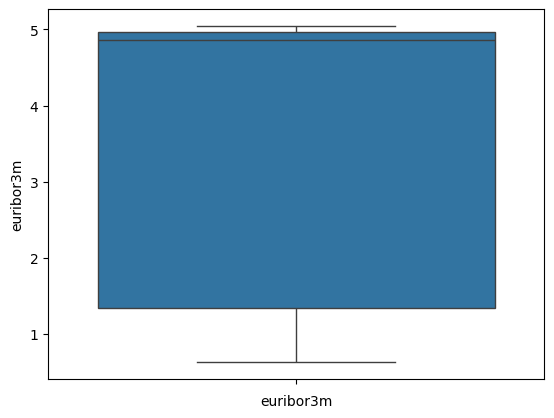

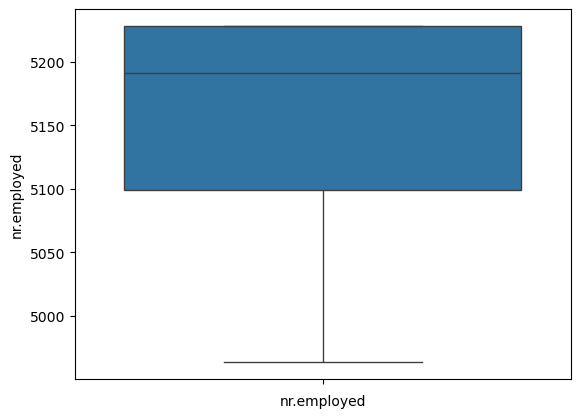

In [156]:
for col in df.columns:
    if df[col].dtype !="object":
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.show()

In [157]:
list = ['age','duration','campaign']

for col in list:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    LB = Q1-1.5*IQR
    UB = Q3+1.5*IQR
    df = df[(df[col]>=LB)&(df[col]<=UB)]
    

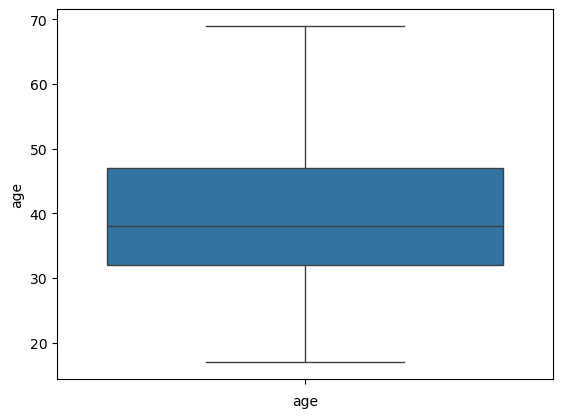

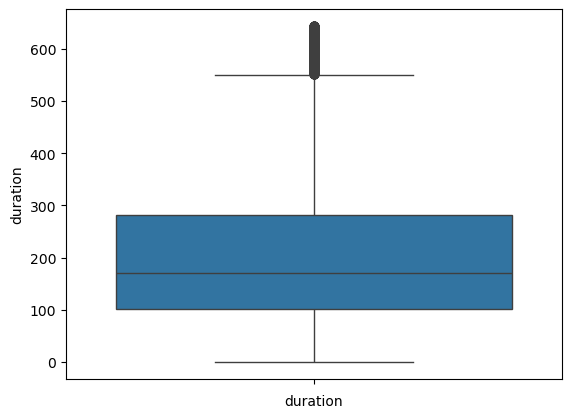

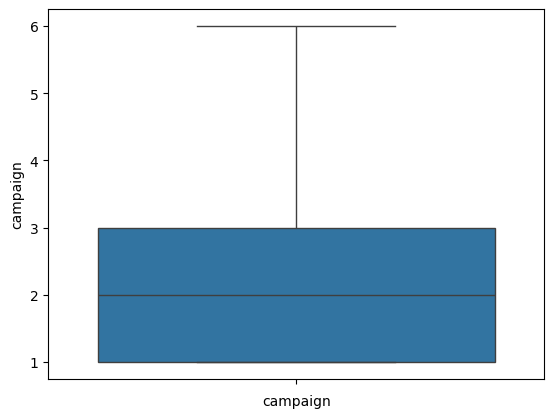

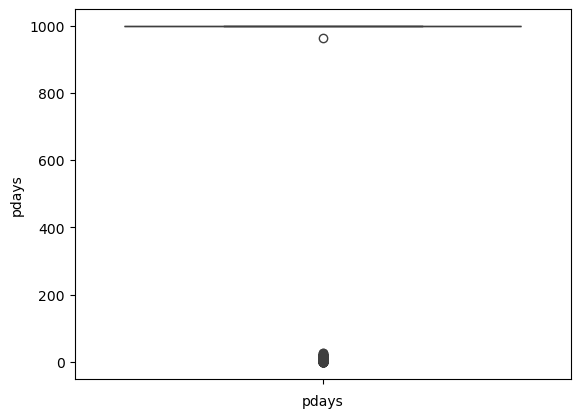

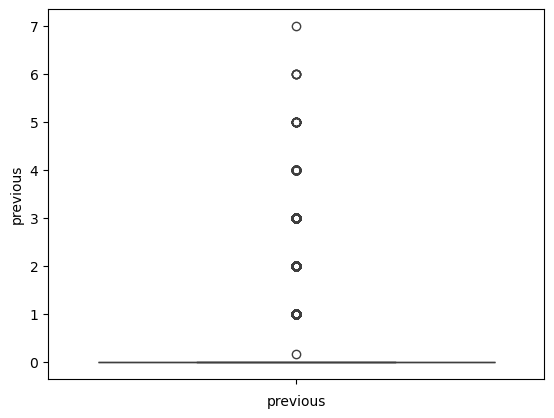

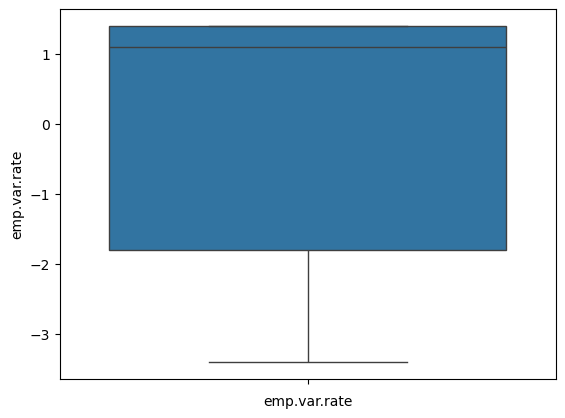

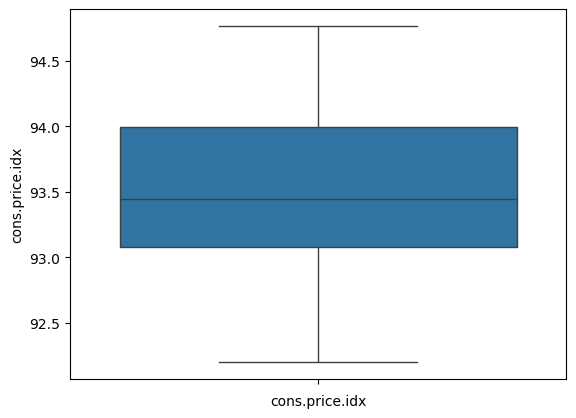

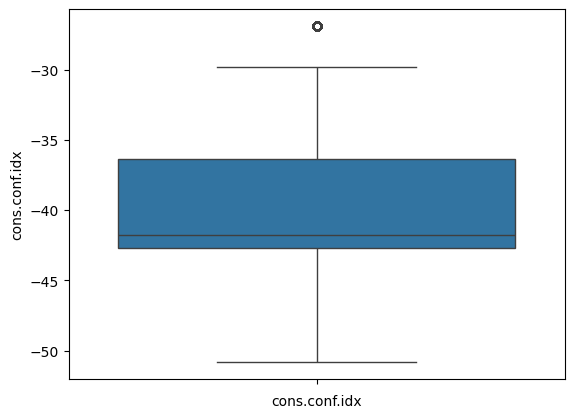

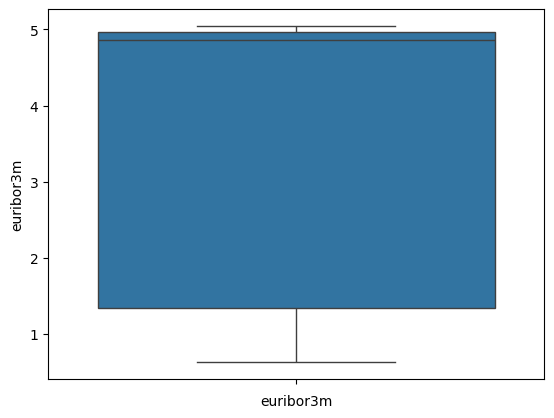

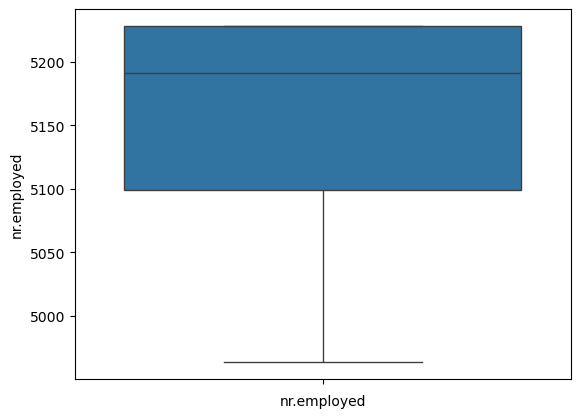

In [158]:
for col in df.columns:
    if df[col].dtype !="object":
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.show()

In [159]:
df1 = df.corr(numeric_only=True)
df1

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.002906,0.011978,0.002573,-0.020312,0.070157,0.036397,0.101917,0.083355,0.067988
duration,0.002906,1.000000,-0.056824,-0.073542,0.045471,-0.051862,-0.000546,0.000046,-0.060228,-0.078259
campaign,0.011978,-0.056824,1.000000,0.043629,-0.059176,0.095977,0.073769,-0.017893,0.080126,0.091158
pdays,0.002573,-0.073542,0.043629,1.000000,-0.573604,0.265035,0.076657,-0.089553,0.290400,0.367656
previous,-0.020312,0.045471,-0.059176,-0.573604,1.000000,-0.420077,-0.208075,-0.062363,-0.452965,-0.499364
emp.var.rate,0.070157,-0.051862,0.095977,0.265035,-0.420077,1.000000,0.777702,0.221389,0.972006,0.906388
cons.price.idx,0.036397,-0.000546,0.073769,0.076657,-0.208075,0.777702,1.000000,0.080084,0.691597,0.524279
cons.conf.idx,0.101917,0.000046,-0.017893,-0.089553,-0.062363,0.221389,0.080084,1.000000,0.301673,0.124473
euribor3m,0.083355,-0.060228,0.080126,0.290400,-0.452965,0.972006,0.691597,0.301673,1.000000,0.944670
nr.employed,0.067988,-0.078259,0.091158,0.367656,-0.499364,0.906388,0.524279,0.124473,0.944670,1.000000


<Axes: >

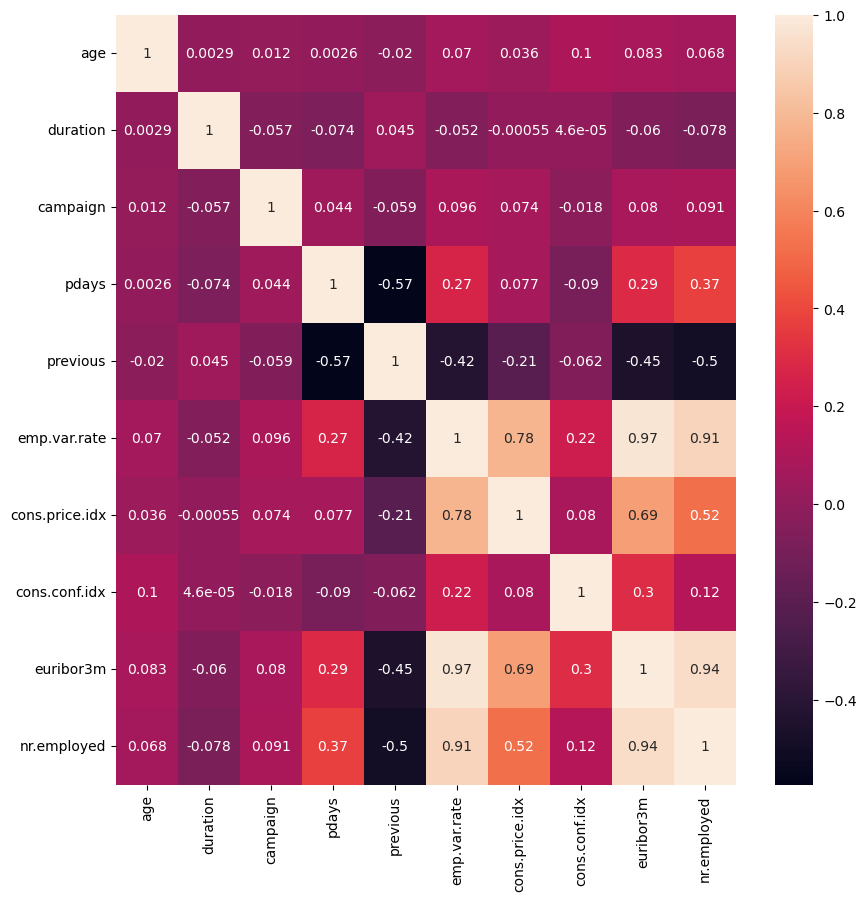

In [160]:
#heatmap
plt.figure(figsize = (10 ,10))
sns.heatmap(df1, annot = True)

In [161]:
#label encoding
from sklearn.preprocessing import LabelEncoder

In [162]:
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype =="object":
        df[i] = le.fit_transform(df[i])

In [163]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.000000,3,1,0,0,0,0,1,6,1,...,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000,0
1,57.000000,7,1,3,1,0,0,1,6,1,...,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000,0
2,37.000000,7,1,3,0,2,0,1,6,1,...,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000,0
3,40.000000,0,1,1,0,0,0,1,6,1,...,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000,0
4,56.000000,7,1,3,0,0,2,1,6,1,...,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.000000,1,1,5,0,0,0,0,7,0,...,1.000000,999.000000,0.000000,1,-1.100000,94.767000,-50.8000,1.028000,4963.600000,0
41185,56.000000,5,1,6,0,2,0,0,7,0,...,2.000000,999.000000,0.000000,1,-1.100000,94.767000,-50.8000,1.028000,4963.600000,0
41186,44.000000,9,1,5,0,0,0,0,7,0,...,1.000000,999.000000,0.000000,1,-1.100000,94.767000,-50.8000,1.028000,4963.600000,1
41188,40.030319,0,1,6,0,2,0,0,6,2,...,2.567676,962.482547,0.173124,1,0.081656,93.575867,-40.5046,3.620787,5166.996405,0


# feature selection
vif-->variance inflation factor---multicolinearty problem <<---------->>
rfe--->recursive feature elimination --- remove unimp feaytures

# vif score
1--no multi <<---------->>
1-5--->moderate -->fine accepted <<---------->>
6-10 -- not prefreabble<<---------->>
10---seriouse issues -- remove

In [164]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [165]:
col_list = []
for col in df.columns:
    if((df[col].dtype !="object")&(col !="y")):
        col_list.append(col)

In [166]:
col_list

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [167]:
x = df[col_list]

In [168]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41184    0
41185    0
41186    1
41188    0
41189    0
Name: y, Length: 35526, dtype: int32

In [169]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.000000,3,1,0,0,0,0,1,6,1,261.000000,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000
1,57.000000,7,1,3,1,0,0,1,6,1,149.000000,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000
2,37.000000,7,1,3,0,2,0,1,6,1,226.000000,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000
3,40.000000,0,1,1,0,0,0,1,6,1,151.000000,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000
4,56.000000,7,1,3,0,0,2,1,6,1,307.000000,1.000000,999.000000,0.000000,1,1.100000,93.994000,-36.4000,4.857000,5191.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.000000,1,1,5,0,0,0,0,7,0,383.000000,1.000000,999.000000,0.000000,1,-1.100000,94.767000,-50.8000,1.028000,4963.600000
41185,56.000000,5,1,6,0,2,0,0,7,0,189.000000,2.000000,999.000000,0.000000,1,-1.100000,94.767000,-50.8000,1.028000,4963.600000
41186,44.000000,9,1,5,0,0,0,0,7,0,442.000000,1.000000,999.000000,0.000000,1,-1.100000,94.767000,-50.8000,1.028000,4963.600000
41188,40.030319,0,1,6,0,2,0,0,6,2,258.281265,2.567676,962.482547,0.173124,1,0.081656,93.575867,-40.5046,3.620787,5166.996405


In [170]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

           feature           VIF
0              age     21.985105
1              job      2.102180
2          marital      5.709837
3        education      4.559342
4          default      1.410347
5          housing      2.211469
6             loan      1.207775
7          contact      2.894694
8            month      6.791677
9      day_of_week      3.099995
10        duration      3.234755
11        campaign      3.617560
12           pdays    168.827508
13        previous      6.083687
14        poutcome     34.436588
15    emp.var.rate     39.050290
16  cons.price.idx  37984.872527
17   cons.conf.idx    131.568165
18       euribor3m    321.676161
19     nr.employed  43279.161950


In [171]:
x.drop("nr.employed",axis=1,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11204\1434238923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop("nr.employed",axis=1,inplace=True)


In [172]:
x.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m'],
      dtype='object')

In [173]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

           feature         VIF
0              age   21.978941
1              job    2.101906
2          marital    5.709093
3        education    4.557887
4          default    1.407760
5          housing    2.211108
6             loan    1.207732
7          contact    2.414695
8            month    5.838983
9      day_of_week    3.099013
10        duration    3.225121
11        campaign    3.604301
12           pdays  168.809267
13        previous    5.984518
14        poutcome   34.162271
15    emp.var.rate   23.101376
16  cons.price.idx  713.734460
17   cons.conf.idx  111.499536
18       euribor3m  130.297562


In [174]:
x.drop("cons.price.idx",axis=1,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11204\1411419218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop("cons.price.idx",axis=1,inplace=True)


In [175]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

          feature        VIF
0             age  20.847572
1             job   2.095893
2         marital   5.558871
3       education   4.504609
4         default   1.407720
5         housing   2.209454
6            loan   1.207216
7         contact   2.326459
8           month   5.795048
9     day_of_week   3.085735
10       duration   3.199852
11       campaign   3.587487
12          pdays  91.830238
13       previous   3.058250
14       poutcome  17.245312
15   emp.var.rate  16.754751
16  cons.conf.idx  73.504462
17      euribor3m  91.216534


In [176]:
x.drop("pdays", axis=1, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11204\2698963385.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop("pdays", axis=1, inplace = True)


In [177]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

          feature        VIF
0             age  19.992698
1             job   2.092500
2         marital   5.432854
3       education   4.451750
4         default   1.407623
5         housing   2.206048
6            loan   1.207028
7         contact   2.260459
8           month   5.749190
9     day_of_week   3.073669
10       duration   3.187755
11       campaign   3.568157
12       previous   1.501479
13       poutcome   7.971443
14   emp.var.rate  12.444968
15  cons.conf.idx  37.950120
16      euribor3m  60.292155


In [178]:
x.drop("euribor3m", axis=1, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11204\2054673540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop("euribor3m", axis=1, inplace = True)


In [179]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

          feature        VIF
0             age  16.709995
1             job   2.085102
2         marital   5.196532
3       education   4.285715
4         default   1.407276
5         housing   2.197843
6            loan   1.206767
7         contact   2.254919
8           month   5.237746
9     day_of_week   3.031475
10       duration   3.179013
11       campaign   3.560721
12       previous   1.483972
13       poutcome   7.821559
14   emp.var.rate   1.556513
15  cons.conf.idx  29.854867


In [180]:
x.drop("cons.conf.idx", axis=1,inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11204\1027658632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop("cons.conf.idx", axis=1,inplace = True)


In [181]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

         feature        VIF
0            age  10.998213
1            job   2.077374
2        marital   4.372254
3      education   4.190634
4        default   1.406124
5        housing   2.160935
6           loan   1.203201
7        contact   2.234170
8          month   4.931961
9    day_of_week   2.970685
10      duration   3.108052
11      campaign   3.391945
12      previous   1.480581
13      poutcome   7.540296
14  emp.var.rate   1.552414


In [182]:
x.drop("age",axis=1,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11204\2046626937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop("age",axis=1,inplace=True)


In [183]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

         feature       VIF
0            job  2.053503
1        marital  4.351919
2      education  4.010880
3        default  1.322171
4        housing  2.111631
5           loan  1.200008
6        contact  2.232954
7          month  4.655937
8    day_of_week  2.888271
9       duration  2.990270
10      campaign  3.190504
11      previous  1.445820
12      poutcome  6.443659
13  emp.var.rate  1.551429


In [184]:
x.drop("poutcome", axis=1,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11204\3110694433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop("poutcome", axis=1,inplace=True)


In [185]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

         feature       VIF
0            job  2.034126
1        marital  4.141947
2      education  3.793973
3        default  1.312781
4        housing  2.079938
5           loan  1.198143
6        contact  2.217937
7          month  4.534080
8    day_of_week  2.804488
9       duration  2.839072
10      campaign  3.067642
11      previous  1.374298
12  emp.var.rate  1.543577


In [186]:
x

,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,emp.var.rate
0,3,1,0,0,0,0,1,6,1,261.000000,1.000000,0.000000,1.100000
1,7,1,3,1,0,0,1,6,1,149.000000,1.000000,0.000000,1.100000
2,7,1,3,0,2,0,1,6,1,226.000000,1.000000,0.000000,1.100000
3,0,1,1,0,0,0,1,6,1,151.000000,1.000000,0.000000,1.100000
4,7,1,3,0,0,2,1,6,1,307.000000,1.000000,0.000000,1.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,1,1,5,0,0,0,0,7,0,383.000000,1.000000,0.000000,-1.100000
41185,5,1,6,0,2,0,0,7,0,189.000000,2.000000,0.000000,-1.100000
41186,9,1,5,0,0,0,0,7,0,442.000000,1.000000,0.000000,-1.100000
41188,0,1,6,0,2,0,0,6,2,258.281265,2.567676,0.173124,0.081656


In [187]:
y = df["y"]
y

0        0
1        0
2        0
3        0
4        0
        ..
41184    0
41185    0
41186    1
41188    0
41189    0
Name: y, Length: 35526, dtype: int32

# model building 

**import necess.. libeary <----------->
data spliting <----------->
train_test_split<----------->
training<----------->
testing<----------->
evaluation**

In [188]:
from sklearn.model_selection import train_test_split

In [189]:
x_train,x_test,y_train,y_test = train_test_split(x,y, train_size=0.80,random_state=0)

In [190]:
x_train

,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,emp.var.rate
36653,0,1,6,0,2,0,0,4,0,133.0,1.0,0.0,-2.9
25035,0,1,5,0,2,0,0,7,3,124.0,1.0,1.0,-0.1
31723,9,1,5,0,2,0,0,6,2,63.0,1.0,0.0,-1.8
13022,1,2,5,1,1,1,0,3,3,392.0,2.0,0.0,1.4
18874,5,1,6,1,2,0,0,1,1,174.0,1.0,0.0,1.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24347,5,1,3,0,2,0,0,7,1,49.0,1.0,0.0,-0.1
37064,0,2,6,0,2,2,0,3,4,122.0,1.0,0.0,-2.9
35152,1,2,2,0,0,0,0,6,0,170.0,2.0,0.0,-1.8
24867,1,1,5,0,2,0,0,7,3,135.0,3.0,0.0,-0.1


In [191]:
from sklearn.linear_model import LogisticRegression

In [192]:
Lr = LogisticRegression()


In [193]:
#training 
Lr.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [194]:
#testing 
y_pred = Lr.predict(x_test)

In [195]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [196]:
from sklearn.metrics import *

In [197]:
accuracy_score(y_pred,y_test)*100

91.3312693498452